In [2]:
import numpy as np 
import pandas as pd


In [19]:
path="C:/Users/HP/Downloads/movies.csv"
movies_df=pd.read_csv(path)
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [20]:
print(movies_df.shape)        # number of rows and columns
print(movies_df.dtypes)       # data type of each column
print(movies_df.isnull().sum()) # count of missing values per column     

(62423, 3)
movieId    int64
title        str
genres       str
dtype: object
movieId    0
title      0
genres     0
dtype: int64


In [21]:
#Extract the year from the title column
movies_df['year']=movies_df['title'].str.extract(r'\((\d{4})\)') 

#replace the year with a space and clean the whitespace
movies_df['title']=movies_df['title'].str.replace(r'\((\d{4})\)','',regex=True).str.strip() 

#replacing (no vlaues listed) with a workable with value
movies_df['genres']=movies_df['genres'].replace('(no genres listed)',np.nan) 

#replace the pipe(|) separating the genre types with a space
movies_df['genres']=movies_df['genres'].str.replace('|', ' ',regex=False)

movies_df.head()


,movieId,title,genres,year
0,1,Toy Story,Adventure Animation Children Comedy Fantasy,1995
1,2,Jumanji,Adventure Children Fantasy,1995
2,3,Grumpier Old Men,Comedy Romance,1995
3,4,Waiting to Exhale,Comedy Drama Romance,1995
4,5,Father of the Bride Part II,Comedy,1995


In [31]:
movies_df['year']=pd.to_numeric(movies_df['year'],errors='coerce')

In [32]:
print(movies_df['year'].isnull().sum())
print(movies_df['genres'].isnull().sum())

146
0


In [34]:
#we drop movies with no genres listed and replace null years with the median
movies_df=movies_df.dropna(subset=['genres'])

movies_df['year']=movies_df['year'].fillna(movies_df['year'].median())
print(movies_df.isnull().sum())
print(movies_df.shape)

movieId    0
title      0
genres     0
year       0
dtype: int64
(57361, 4)


In [35]:
#Now lets move to the tags dataframe
path_tags="C:/Users/HP/Downloads/tags.csv"
tags_df=pd.read_csv(path_tags)
tags_df.head()

,userId,movieId,tag,timestamp
0,3,260,classic,1439472355
1,3,260,sci-fi,1439472256
2,4,1732,dark comedy,1573943598
3,4,1732,great dialogue,1573943604
4,4,7569,so bad it's good,1573943455


In [37]:
tags_df=tags_df.drop(columns='timestamp')
tags_df.head()

,userId,movieId,tag
0,3,260,classic
1,3,260,sci-fi
2,4,1732,dark comedy
3,4,1732,great dialogue
4,4,7569,so bad it's good


In [38]:
print(tags_df.shape)
print(tags_df.isnull().sum())
print(tags_df.dtypes)

(1093360, 3)
userId      0
movieId     0
tag        16
dtype: int64
userId     int64
movieId    int64
tag          str
dtype: object


In [40]:
#Drop null values
tags_df=tags_df.dropna(subset=['tag'])
#lower the tags for consistency
tags_df['tag']=tags_df['tag'].str.lower().str.strip()

print(tags_df.shape)
print(tags_df.isnull().sum())


(1093344, 3)
userId     0
movieId    0
tag        0
dtype: int64


In [44]:
#combine all tags for each movie
tags_agg=tags_df.groupby('movieId')['tag'].apply(lambda x:' '.join(x)).reset_index()

#rename for clarity
tags_agg.columns=['movieId','tags']

print(tags_agg.shape)
tags_agg.head()

(45251, 2)


,movieId,tags
0,1,owned imdb top 250 pixar pixar time travel chi...
1,2,robin williams time travel fantasy based on ch...
2,3,funny best friend duringcreditsstinger fishing...
3,4,based on novel or book chick flick divorce int...
4,5,aging baby confidence contraception daughter g...


In [45]:
#merge tags into movies- left joins all the movies even those with no tags
movies_df=movies_df.merge(tags_agg, on='movieId', how='left')

#Movies with no tags get an empty str instead of NaN
movies_df['tags']=movies_df['tags'].fillna('')

print(movies_df.shape)
movies_df.head()

(57361, 5)


,movieId,title,genres,year,tags
0,1,Toy Story,Adventure Animation Children Comedy Fantasy,1995.0,owned imdb top 250 pixar pixar time travel chi...
1,2,Jumanji,Adventure Children Fantasy,1995.0,robin williams time travel fantasy based on ch...
2,3,Grumpier Old Men,Comedy Romance,1995.0,funny best friend duringcreditsstinger fishing...
3,4,Waiting to Exhale,Comedy Drama Romance,1995.0,based on novel or book chick flick divorce int...
4,5,Father of the Bride Part II,Comedy,1995.0,aging baby confidence contraception daughter g...


In [46]:
#join the tags and genres to for one combined column (metadata)
movies_df['metadata']=movies_df['genres']+' '+movies_df['tags']

#lowercase everything for consistency
movies_df['metadata']=movies_df['metadata'].str.lower().str.strip()

In [47]:
movies_df.head()

,movieId,title,genres,year,tags,metadata
0,1,Toy Story,Adventure Animation Children Comedy Fantasy,1995.0,owned imdb top 250 pixar pixar time travel chi...,adventure animation children comedy fantasy ow...
1,2,Jumanji,Adventure Children Fantasy,1995.0,robin williams time travel fantasy based on ch...,adventure children fantasy robin williams time...
2,3,Grumpier Old Men,Comedy Romance,1995.0,funny best friend duringcreditsstinger fishing...,comedy romance funny best friend duringcredits...
3,4,Waiting to Exhale,Comedy Drama Romance,1995.0,based on novel or book chick flick divorce int...,comedy drama romance based on novel or book ch...
4,5,Father of the Bride Part II,Comedy,1995.0,aging baby confidence contraception daughter g...,comedy aging baby confidence contraception dau...


In [51]:
path_train="C:/Users/HP/Downloads/train.csv"
train_df=pd.read_csv(path_train, dtype={'userId': 'int32',    # smaller int type saves memory
    'movieId': 'int32',   # smaller int type saves memory
    'rating': 'float32'   # smaller float type saves memory
})


In [53]:
train_df=train_df.drop(columns='timestamp')

In [55]:
print(train_df.shape)
print(train_df.isnull().sum())

(10000038, 3)
userId     0
movieId    0
rating     0
dtype: int64


In [58]:
path_test="C:/Users/HP/Downloads/test.csv"
test_df = pd.read_csv(path_test, dtype={
    'userId': 'int32',
    'movieId': 'int32'
})

print(test_df.shape)
print(test_df.dtypes)
print(test_df.isnull().sum())
test_df.head()

(5000019, 2)
userId     int32
movieId    int32
dtype: object
userId     0
movieId    0
dtype: int64


,userId,movieId
0,1,2011
1,1,4144
2,1,5767
3,1,6711
4,1,7318


In [59]:
test_df['Id']=test_df['userId'].astype(str)+'_'+test_df['movieId'].astype(str)

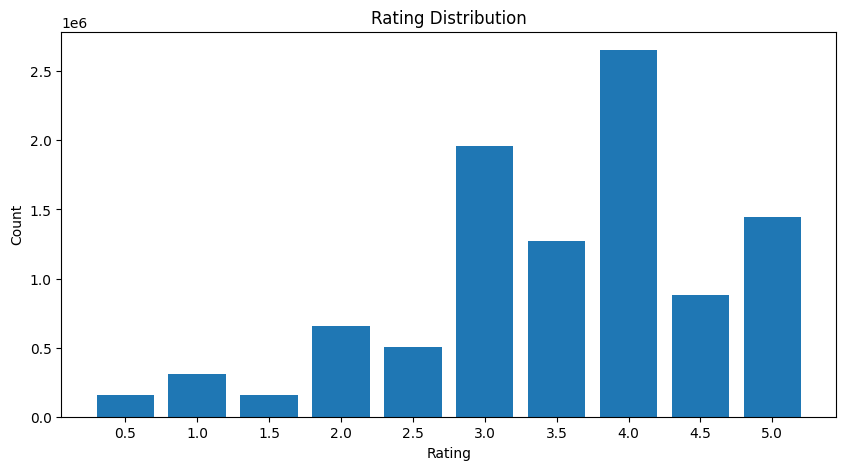

count    1.000004e+07
mean     3.533395e+00
std      1.036790e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


In [60]:
import matplotlib.pyplot as plt

# Count how many times each rating value appears
rating_counts = train_df['rating'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(rating_counts.index, rating_counts.values, width=0.4)  # bar for each rating value
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rating_counts.index)  # show all rating values on x axis
plt.show()

print(train_df['rating'].describe())  # summary statistics

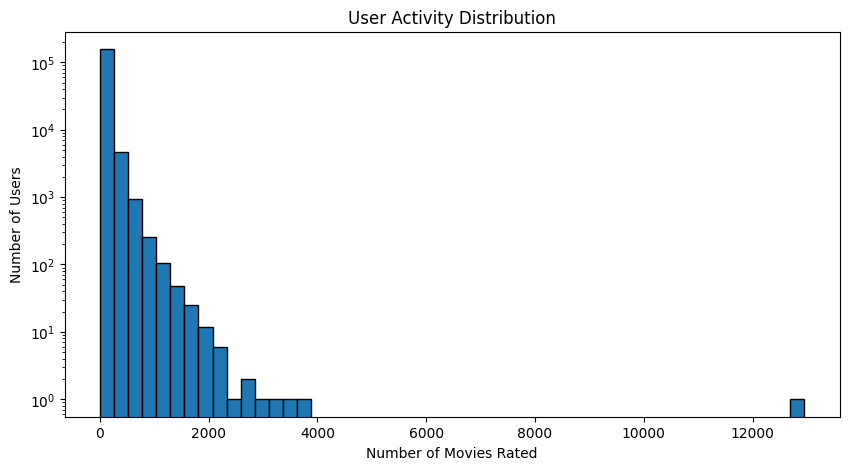

count    162541.000000
mean         61.523173
std         107.410889
min           1.000000
25%          14.000000
50%          28.000000
75%          65.000000
max       12952.000000
Name: rating, dtype: float64


In [61]:
# Count how many movies each user has rated
user_activity = train_df.groupby('userId')['rating'].count()

plt.figure(figsize=(10, 5))
plt.hist(user_activity, bins=50, edgecolor='black')  # distribute users into 50 buckets
plt.title('User Activity Distribution')
plt.xlabel('Number of Movies Rated')
plt.ylabel('Number of Users')
plt.yscale('log')   # log scale because a few users rate thousands of movies
plt.show()

print(user_activity.describe())

In [62]:
# How many users have rated more than 5000 movies
power_users = user_activity[user_activity > 5000]
print(f"Number of power users: {len(power_users)}")
print(f"They represent: {len(power_users)/len(user_activity)*100:.2f}% of all users")

# What percentage of total ratings do they contribute
power_user_ratings = train_df[train_df['userId'].isin(power_users.index)]
print(f"Ratings from power users: {len(power_user_ratings)/len(train_df)*100:.2f}% of all ratings")

Number of power users: 1
They represent: 0.00% of all users
Ratings from power users: 0.13% of all ratings


Power user mean rating: 3.09
Everyone else mean rating: 3.53


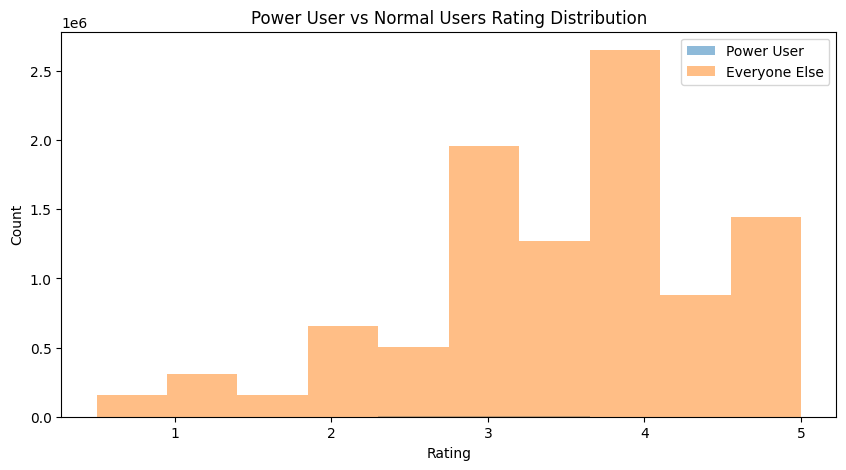

In [63]:
# Get the power user's id
power_user_id = power_users.index[0]

# Compare their rating distribution vs everyone else
power_user_ratings = train_df[train_df['userId'] == power_user_id]['rating']
normal_ratings = train_df[train_df['userId'] != power_user_id]['rating']

print(f"Power user mean rating: {power_user_ratings.mean():.2f}")
print(f"Everyone else mean rating: {normal_ratings.mean():.2f}")

plt.figure(figsize=(10,5))
plt.hist(power_user_ratings, bins=10, alpha=0.5, label='Power User')  # alpha makes it transparent
plt.hist(normal_ratings, bins=10, alpha=0.5, label='Everyone Else')
plt.legend()
plt.title('Power User vs Normal Users Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

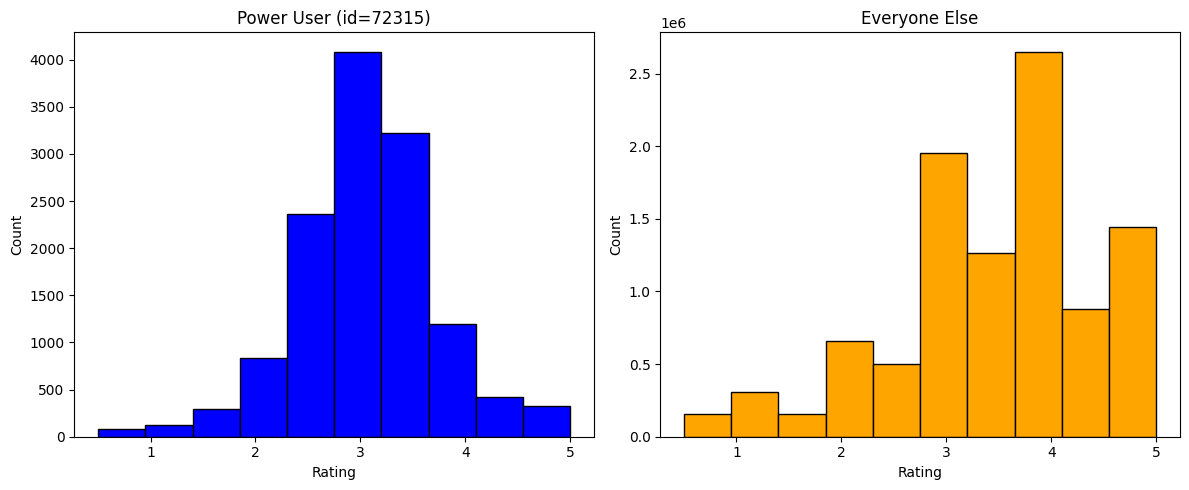

Power user mean: 3.09
Everyone else mean: 3.53


In [64]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # 2 side by side plots

# Power user plot
ax1.hist(power_user_ratings, bins=10, edgecolor='black', color='blue')
ax1.set_title(f'Power User (id={power_user_id})')
ax1.set_xlabel('Rating')
ax1.set_ylabel('Count')

# Everyone else plot
ax2.hist(normal_ratings, bins=10, edgecolor='black', color='orange')
ax2.set_title('Everyone Else')
ax2.set_xlabel('Rating')
ax2.set_ylabel('Count')

plt.tight_layout()  # prevents plots from overlapping
plt.show()

print(f"Power user mean: {power_user_ratings.mean():.2f}")
print(f"Everyone else mean: {normal_ratings.mean():.2f}")

In [65]:
# Remove the power user from train_df
train_df = train_df[train_df['userId'] != power_user_id]

print(f"New train size: {len(train_df):,}")        # confirm rows removed
print(f"New mean rating: {train_df['rating'].mean():.2f}")  # should be slightly higher now

New train size: 9,987,086
New mean rating: 3.53


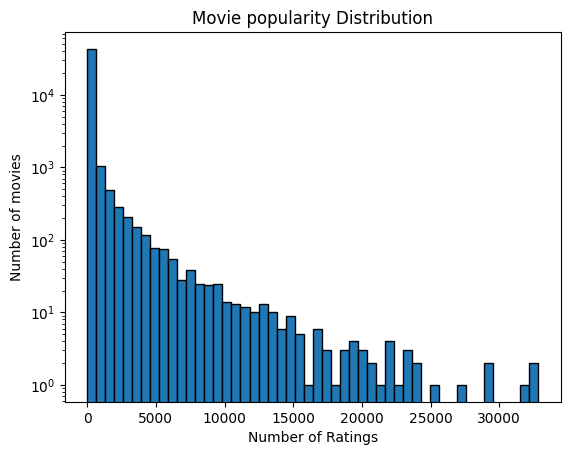

count    45844.000000
mean       217.849359
std       1119.586909
min          1.000000
25%          1.000000
50%          4.000000
75%         29.000000
max      32831.000000
Name: rating, dtype: float64

Movies with less than 5 ratings: 23,349


In [67]:
movie_popularity=train_df.groupby('movieId')['rating'].count().sort_values(ascending=False)

plt.Figure(figsize=(10,5))
plt.hist(movie_popularity,bins=50,edgecolor='black')
plt.title('Movie popularity Distribution')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of movies')
plt.yscale('log')
plt.show()

print(movie_popularity.describe())
print(f"\nMovies with less than 5 ratings: {len(movie_popularity[movie_popularity < 5]):,}")

In [68]:
# Get movieIds with at least 5 ratings
popular_movies = movie_popularity[movie_popularity >= 5].index

# Keep only rows where movieId is in popular_movies
train_df = train_df[train_df['movieId'].isin(popular_movies)]

print(f"New train size: {len(train_df):,}")                    # confirm rows removed
print(f"Remaining unique movies: {train_df['movieId'].nunique():,}")  # movies left

New train size: 9,944,435
Remaining unique movies: 22,495


Feature Engineering

In [70]:
user_features=train_df.groupby('userId')['rating'].agg(
    user_mean='mean',
    user_std='std',
    user_count='count'
).reset_index()

print(user_features.shape)
user_features.head()

(162540, 4)


,userId,user_mean,user_std,user_count
0,1,3.910714,1.000496,28
1,2,3.416667,1.508194,72
2,3,3.691235,0.620712,251
3,4,3.312500,1.088900,88
4,5,3.885714,0.963188,35


In [71]:
movie_features=train_df.groupby('movieId')['rating'].agg(
    movie_mean='mean',
    movie_std='std',
    movie_count='count'
).reset_index()

print(movie_features.shape)
movie_features.head()

(22495, 4)


,movieId,movie_mean,movie_std,movie_count
0,1,3.889971,0.924249,23062
1,2,3.263441,0.966790,9653
2,3,3.132325,1.016368,4727
3,4,2.878099,1.073617,968
4,5,3.059165,0.995982,4648


In [78]:
# Start fresh from the original train_df with only userId, movieId, rating
train_featured = train_df[['userId', 'movieId', 'rating']].copy()

# Merge user features
train_featured = train_featured.merge(user_features, on='userId', how='left')

# Merge movie features
train_featured = train_featured.merge(movie_features, on='movieId', how='left')

# Merge year only
train_featured = train_featured.merge(
    movies_df[['movieId', 'year']], on='movieId', how='left'
)

# Fill missing years
train_featured['year'] = train_featured['year'].fillna(train_featured['year'].median())


print(train_featured.shape)
print(train_featured.columns.tolist())
print(train_featured.isnull().sum())

(9944435, 10)
['userId', 'movieId', 'rating', 'user_mean', 'user_std', 'user_count', 'movie_mean', 'movie_std', 'movie_count', 'year']
userId         0
movieId        0
rating         0
user_mean      0
user_std       6
user_count     0
movie_mean     0
movie_std      0
movie_count    0
year           0
dtype: int64


In [79]:

train_featured['user_std']=train_featured['user_std'].fillna(0)
print(train_featured.isnull().sum())

userId         0
movieId        0
rating         0
user_mean      0
user_std       0
user_count     0
movie_mean     0
movie_std      0
movie_count    0
year           0
dtype: int64


Build and test model

In [81]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 676.8 kB/s eta 0:02:30
   ---------------------------------------- 0.5/101.7 MB 676.8 kB/s eta 0:02:30
   ---------------------------------------- 1.0/101.7 MB 1.0 MB/s eta 0:01:37
    --------------------------------------- 1.3/101.7 MB 1.0 MB/s eta 0:01:36
    --------------------------------------- 1.3/101.7 MB 1.0 MB/s eta 0:01:36
    --------------------------------------- 1.6/101.7 MB 963.6 kB/s eta 0:01:44
    --------------------------------------- 1.6/101.7 MB 963.6 kB/s eta 0:01:44
    --------------------------------------- 2.1/101.7 MB 1.0 MB/s eta 0:01:38
    ---------

In [83]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
print(xgb.__version__)

3.2.0


In [85]:
feature_cols=[
    'user_mean',
    'user_std',
    'user_count',
    'movie_mean',
    'movie_std',
    'movie_count',
    'year'
]

X=train_featured[feature_cols]
y=train_featured['rating']

#split the data to 80% training and 20% testing
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)

(7955548, 7)
(1988887, 7)


In [87]:
# fit the model
model=xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=1
)
model.fit(X_train,y_train,eval_set=[(X_test,y_test)],verbose=50)

[0]	validation_0-rmse:1.03780
[50]	validation_0-rmse:0.85377
[100]	validation_0-rmse:0.85200
[150]	validation_0-rmse:0.85134
[199]	validation_0-rmse:0.85088


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [88]:
# Make predictions on the validation set
val_predictions = model.predict(X_test)

# Calculate RMSE — lower is better
rmse = np.sqrt(mean_squared_error(y_test, val_predictions))
print(f"Validation RMSE: {rmse:.4f}")

# See which features were most important
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

Validation RMSE: 0.8509
       feature  importance
0    user_mean    0.455251
3   movie_mean    0.439775
4    movie_std    0.039899
1     user_std    0.034634
2   user_count    0.013853
5  movie_count    0.010515
6         year    0.006072


In [89]:
path_test="C:/Users/HP/Downloads/test.csv"
test_df=pd.read_csv(path_test)

In [90]:
# Merge the same features onto test_df
test_featured = test_df.merge(user_features, on='userId', how='left')
test_featured = test_featured.merge(movie_features, on='movieId', how='left')
test_featured = test_featured.merge(
    movies_df[['movieId', 'year']], on='movieId', how='left'
)

# Fill missing values — cold start users/movies get global averages
global_mean = train_df['rating'].mean()
test_featured['user_mean']   = test_featured['user_mean'].fillna(global_mean)
test_featured['user_std']    = test_featured['user_std'].fillna(0)
test_featured['user_count']  = test_featured['user_count'].fillna(0)
test_featured['movie_mean']  = test_featured['movie_mean'].fillna(global_mean)
test_featured['movie_std']   = test_featured['movie_std'].fillna(0)
test_featured['movie_count'] = test_featured['movie_count'].fillna(0)
test_featured['year']        = test_featured['year'].fillna(test_featured['year'].median())

print(test_featured.isnull().sum())

userId         0
movieId        0
user_mean      0
user_std       0
user_count     0
movie_mean     0
movie_std      0
movie_count    0
year           0
dtype: int64


In [92]:
# Recreate the Id column
test_featured['Id'] = test_featured['userId'].astype(str) + '_' + test_featured['movieId'].astype(str)

# Now predict and save
test_predictions = model.predict(test_featured[feature_cols])
test_predictions = np.clip(test_predictions, 0.5, 5.0)

submission = pd.DataFrame({
    'Id': test_featured['Id'],
    'rating': test_predictions
})

submission.to_csv('submission.csv', index=False)
print(submission.shape)
print(submission.head(10))

(5000019, 2)
       Id    rating
0  1_2011  3.805061
1  1_4144  4.297696
2  1_5767  4.201234
3  1_6711  4.010556
4  1_7318  3.566801
5  1_8405  4.093968
6  1_8786  4.097289
7   2_150  3.752992
8   2_356  3.824982
9   2_497  3.812291


In [96]:
from IPython.display import FileLink
FileLink('submission.csv')

c:\Users\HP\AppData\Local\Programs\Microsoft VS Code\submission.csv